In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from zipfile import ZipFile
from scipy.io import wavfile
from scipy import signal as sg
from IPython.display import Audio, display

archive_path = next(Path(".").glob("**/YoungPeople.zip"), None)

if archive_path is None:
    raise FileNotFoundError("Положи YoungPeople.zip в корень проекта или в data/")

with ZipFile(archive_path) as z:
    wav_name = next(name for name in z.namelist() if name.lower().endswith(".wav"))
    z.extract(wav_name, "data")

fs, speech = wavfile.read(Path("data") / wav_name)

if speech.ndim > 1:
    speech = speech.mean(axis=1)

speech = speech.astype(float)
speech = speech / np.max(np.abs(speech))
time = np.arange(len(speech)) / fs

print(f"Файл: {wav_name}")
print(f"Частота дискретизации: {fs} Гц")
print(f"Длительность: {len(speech) / fs:.2f} сек")
display(Audio(speech, rate=fs))


Файл: YoungPeople.wav
Частота дискретизации: 44100 Гц
Длительность: 1.54 сек


In [2]:
window_ms = 40
window_size = int(fs * window_ms / 1000)
overlap = window_size // 2

frequencies, times, spectrum = sg.spectrogram(
    speech,
    fs=fs,
    window="hann",
    nperseg=window_size,
    noverlap=overlap,
    mode="magnitude"
)

spectrum_db = 20 * np.log10(spectrum + 1e-10)

print(f"Размер окна: {window_ms} мс")
print(f"Размер окна в отсчетах: {window_size}")
print(f"Перекрытие: {overlap}")


Размер окна: 40 мс
Размер окна в отсчетах: 1764
Перекрытие: 882


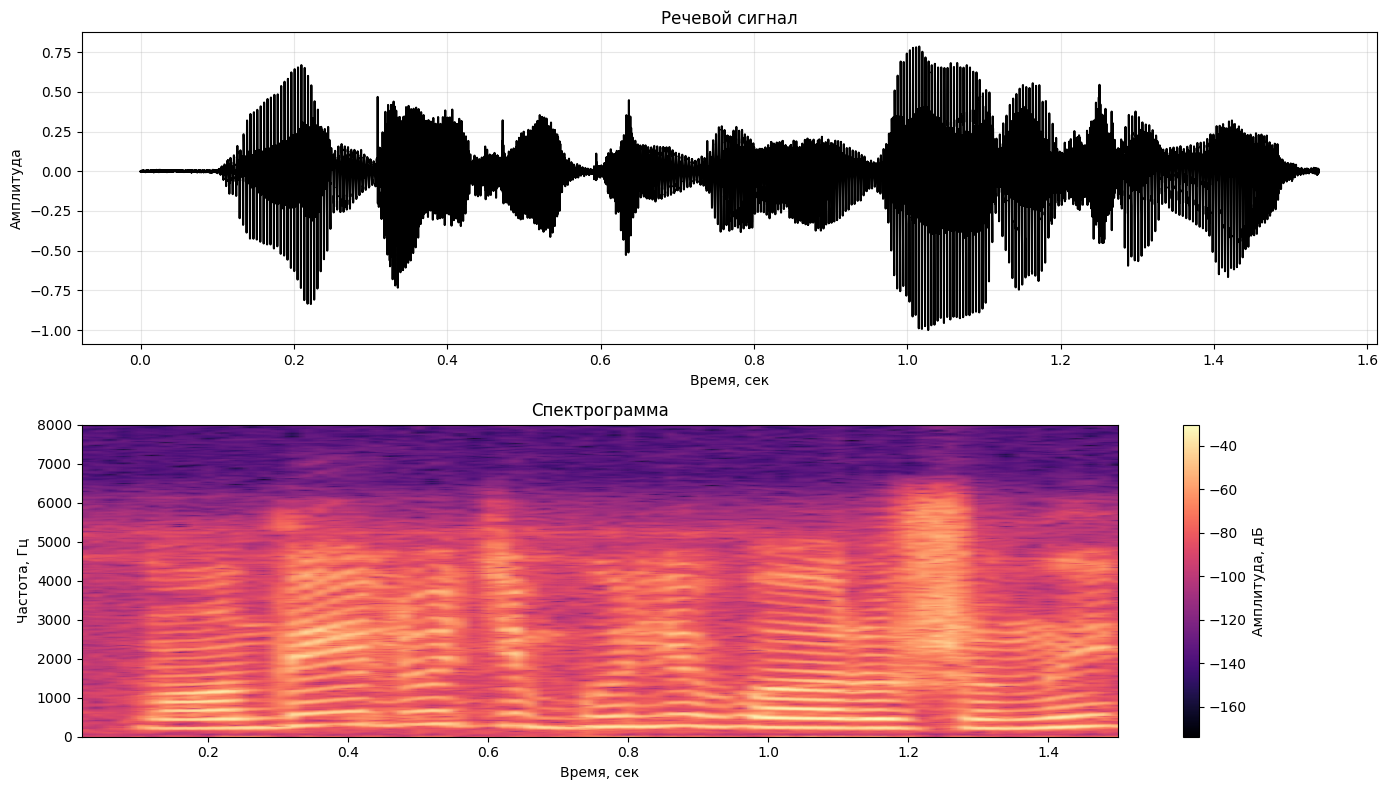

In [3]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(time, speech, color="black")
plt.title("Речевой сигнал")
plt.xlabel("Время, сек")
plt.ylabel("Амплитуда")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.pcolormesh(times, frequencies, spectrum_db, shading="gouraud", cmap="magma")
plt.ylim(0, 8000)
plt.title("Спектрограмма")
plt.xlabel("Время, сек")
plt.ylabel("Частота, Гц")
plt.colorbar(label="Амплитуда, дБ")

plt.tight_layout()
plt.show()


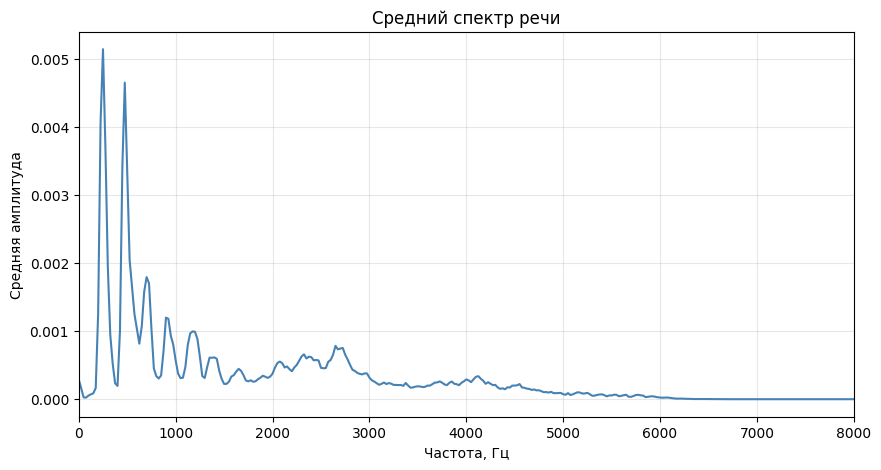

In [4]:
mean_spectrum = spectrum.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(frequencies, mean_spectrum, color="steelblue")
plt.xlim(0, 8000)
plt.xlabel("Частота, Гц")
plt.ylabel("Средняя амплитуда")
plt.title("Средний спектр речи")
plt.grid(True, alpha=0.3)
plt.show()


## Выводы

Гласные звуки на спектрограмме выглядят как протяженные участки с выраженными полосами энергии.  
Основная энергия гласных обычно сосредоточена в низких и средних частотах, а полосы соответствуют формантам.

Согласные звуки чаще короче по времени. Для шумных согласных заметна энергия в более высоких частотах, а взрывные согласные выглядят как короткие вертикальные всплески.
